# Projectile Motion with Atmospheric Drag

Euler trajectories for vacuum and drag models, altitude-dependent air density, and optimal launch angles.

Computational physics coursework by Udayan Sharma. Original code comments and saved outputs are retained. See the repository README for execution notes.


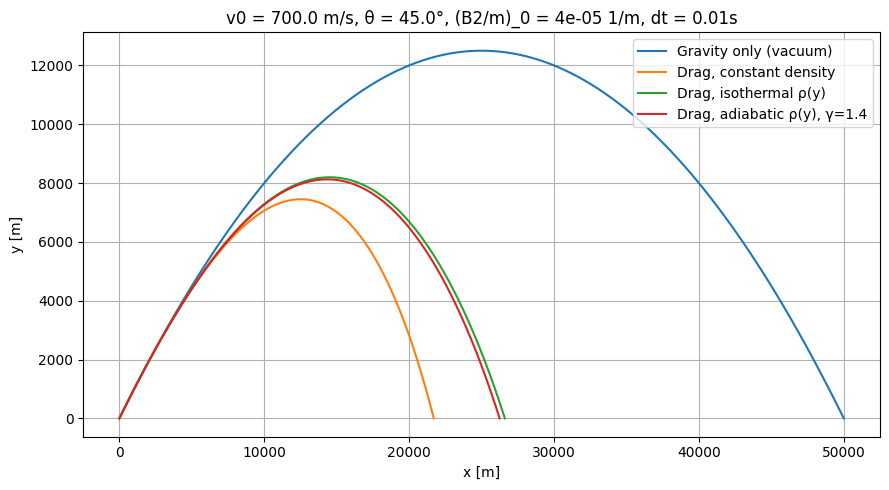

In [ ]:
# Cannon ball trajectory computed via Euler approximation
# assumes: i) drag force F = - B_2 * v^2
#          ii) isothermal air density model: rho(y) = rho(0) * exp(-y / y0)

import math;
import numpy as np;
import matplotlib.pyplot as plt;

g = 9.8;

#  parameters from handout
v0 = 700.0;
theta = 45.0;
B2_m0 = 4e-5;
dt = 0.01;

# isothermal parameter
y0scale = 1e4;

# adiabatic parameters
gamma = 1.4;
a = 9.8e-3;
T0 = 293.0;

def rho_ratio(model, y, y0scale = 1e4, gamma = 1.4, a = 9.8e-3, T0 = 293.0):

    if model == "constant":
        return 1.0;

    if model == "isothermal":
        return math.exp(-y / y0scale);

    if model == "adiabatic":
        base = 1.0 - (a * y / T0);
        return 0.0 if base <= 0 else base ** (1.0 / (gamma - 1.0));

    raise ValueError("bad model for rho_ratio");

def trajectory (v0 = 700.0, theta_deg = 45.0, B2_m0 = 4e-5, dt = 0.01, model = "vacuum", y0scale = 1e4, gamma = 1.4, a = 9.8e-3,
              T0 = 293.0, tmax = 600.0):

    theta = math.radians(theta_deg);
    x, y = 0.0, 0.0;
    vx, vy = v0 * math.cos(theta), v0 * math.sin(theta);
    xs, ys, ts = [x], [y], [0.0];
    nsteps = int(tmax/dt);

    for i in range(nsteps):

        t = (i + 1) * dt;
        # acceleration
        if model == "vacuum":
            ax, ay = 0.0, -g;
        else:
            v = math.hypot(vx, vy);
            rr = rho_ratio(model, y, y0scale = y0scale, gamma = gamma, a = a, T0 = T0);
            k = B2_m0 * rr;
            ax = -k * v * vx;
            ay = -g - k * v * vy;

        # Euler update
        x_new = x + vx * dt;
        y_new = y + vy * dt;
        vx_new = vx + ax * dt;
        vy_new = vy + ay * dt;

        xs.append(x_new);
        ys.append(y_new);
        ts.append(t)
        x, y, vx, vy = x_new, y_new, vx_new, vy_new;

        if y <= 0.0 and i > 0:
            break;

    # interpolate landing point to y=0
    if ys[-1] < 0 and len(ys) >= 2:
        x1, y1 = xs[-2], ys[-2];
        x2, y2 = xs[-1], ys[-1];
        t1, t2 = ts[-2], ts[-1];
        frac = y1 / (y1 - y2) if (y1 - y2) != 0 else 1.0
        xs[-1] = x1 + frac * (x2 - x1);
        ys[-1] = 0.0;
        ts[-1] = t1 + frac * (t2 - t1);

    return np.array(xs), np.array(ys), np.array(ts);


models = ["vacuum", "constant", "isothermal", "adiabatic"];
labels = {"vacuum": "Gravity only (vacuum)", "constant": "Drag, constant density", "isothermal": "Drag, isothermal ρ(y)",
          "adiabatic": "Drag, adiabatic ρ(y), γ=1.4",};

plt.figure(figsize = (9,5));

for m in models:
    if m == "vacuum":
        x,y,t = trajectory(v0, theta, B2_m0, dt, model = "vacuum");

    elif m == "constant":
        x,y,t = trajectory(v0, theta, B2_m0, dt, model = "constant", y0scale = y0scale, gamma = gamma, a = a, T0 = T0);

    elif m == "isothermal":
        x,y,t = trajectory(v0, theta, B2_m0, dt, model = "isothermal", y0scale = y0scale, gamma = gamma, a = a, T0 = T0);

    else:
        x,y,t = trajectory(v0, theta, B2_m0, dt, model = "adiabatic", y0scale = y0scale, gamma = gamma, a = a, T0 = T0);

    plt.plot(x, y, label = labels[m]);

plt.xlabel("x [m]");
plt.ylabel("y [m]");
plt.title(f"v0 = {v0} m/s, θ = {theta}°, (B2/m)_0 = {B2_m0} 1/m, dt = {dt}s");
plt.legend();
plt.grid(True);
plt.tight_layout();
plt.show();

# EOF



In [ ]:
# Cannon shell (Euler), 4 models + optimal angle via bisection
# Find θ* that maximizes range R(θ) to 0.1°, estimate Rmax error by halving dt

import math;
import numpy as np;
import matplotlib.pyplot as plt;

g = 9.8;

#  parameters
v0 = 700.0;
B2_m0 = 4e-5;
y0scale = 1e4; # isothermal scale height (starter choice)
gamma = 1.4;
a_lapse = 9.8e-3;
T0 = 293.0;
models = ["vacuum", "constant", "isothermal", "adiabatic"]
labels = {"vacuum": "Gravity only (vacuum)", "constant": "Drag, constant density", "isothermal": "Drag, isothermal ρ(y)",
    "adiabatic": "Drag, adiabatic ρ(y), γ=1.4",};

# Density factor f(y)=ρ(y)/ρ0 (so (B2/m)(y)=(B2/m)0*f(y))
def f_rho(model, y):
    if model == "constant":
      return 1.0;
    if model == "isothermal":
      return math.exp(-y / y0scale);
    if model == "adiabatic":
        base = 1.0 - a_lapse * y / T0;
        return 0.0 if base <= 0 else base ** (1.0 / (gamma - 1.0));

    return 0.0;  # vacuum never uses it

# Trajectory + range using Euler, with landing interpolation
def trajectory_range(theta_deg, model, dt, tmax = 600.0, store = False):
    angle = math.radians(theta_deg);
    x = y = 0.0;
    vx, vy = v0 * math.cos(angle), v0 * math.sin(angle);

    if store:
        xs, ys = [x], [y];

    for _ in range(int(tmax / dt)):
        # acceleration
        if model == "vacuum":
            ax, ay = 0.0, -g;
        else:
            v = math.hypot(vx, vy);
            k = B2_m0 * f_rho(model, y);
            ax = -k * v * vx;
            ay = -g - k * v * vy;

        # Euler
        x2 = x + vx * dt;
        y2 = y + vy * dt;
        vx2 = vx + ax * dt;
        vy2 = vy + ay * dt;

        if store:
            xs.append(x2); ys.append(y2);

        # detect ground-crossing (after at least 1 step)
        if y2 <= 0.0 and (x != 0.0 or y != 0.0):
            # linear interpolate last segment to y=0
            frac = y / (y - y2) if (y - y2) != 0 else 1.0
            x_land = x + frac * (x2 - x);
            if store:
                xs[-1] = x_land;
                ys[-1] = 0.0;
                return np.array(xs), np.array(ys);
            return x_land;

        x, y, vx, vy = x2, y2, vx2, vy2;

    # if somehow never lands in tmax, just return last x
    if store:
        return np.array(xs), np.array(ys);
    return x;

# Maximize range with bisection on derivative sign
def optimal_angle(model, dt, tol_deg = 0.1, h = 0.2):
    def R(angle):  return trajectory_range(angle, model, dt);
    def dR(angle): return (R(angle + h) - R(angle - h)) / (2.0 * h);

    # bracket: find a,b with dR(a)>0 and dR(b)<0
    a = 2.0;
    fa = dR(a);
    b = None;
    for angle in np.arange(3.0, 88.0, 1.0):
        fb = dR(angle)
        if fa > 0 and fb < 0:
            b = float(angle); break;
        a = float(angle);
        fa = fb;

    # fallback (rare): coarse grid max
    if b is None:
        thetas = np.arange(2.0, 88.0 + 1e-12, 0.1);
        Rs = np.array([R(angle) for th in thetas]);
        j = int(np.argmax(Rs));
        angle = float(thetas[j]);
        return round(angle, 1), float(Rs[j]);

    # bisection on root of dR
    a0, b0 = a, b;
    while (b - a) > tol_deg:
        m = 0.5 * (a + b);
        if dR(m) > 0:
            a = m;
        else:
            b = m;

    angle = round(0.5 * (a + b), 1)
    return angle, R(angle);

dt1, dt2 = 0.01, 0.005;

print("\nTask 2: θ* to 0.1° and Rmax accuracy via dt halving\n");
print(f"{'model':<12} {'θ*(dt)':>8} {'Rmax(dt) [m]':>14} {'θ*(dt/2)':>10} {'Rmax(dt/2) [m]':>16} {'err_R(dt)~2|ΔR| [m]':>20}");
print("-"*92);

for m in models:
    angle1, R1 = optimal_angle(m, dt1);
    angle2, R2 = optimal_angle(m, dt2);
    err_est = 2.0 * abs(R1 - R2);
    print(f"{m:<12} {angle1:>8.1f} {R1:>14.3f} {angle2:>10.1f} {R2:>16.3f} {err_est:>20.3f}");

# EOF




Task 2: θ* to 0.1° and Rmax accuracy via dt halving

model          θ*(dt)   Rmax(dt) [m]   θ*(dt/2)   Rmax(dt/2) [m]  err_R(dt)~2|ΔR| [m]
--------------------------------------------------------------------------------------------
vacuum           45.0      50004.950       45.0        50002.475                4.950
constant         38.8      22070.050       38.8        22069.625                0.850
isothermal       46.0      26621.545       46.0        26621.523                0.042
adiabatic        46.2      26265.478       46.2        26265.407                0.141
